<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/XOR_gate_hard_coded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XOR GATE – TWO LAYER PERCEPTRON (HARD-CODED WEIGHTS)
-----------------------------------------------------------------

Hidden Neuron 1 (OR):  z1 = x1 + x2 - 0.5
Hidden Neuron 2 (AND): z2 = x1 + x2 - 1.5
Output Neuron: y = step(z1 - 2*z2 - 0.5)

PREDICTIONS
Input (0, 0) | h1 = 0, h2 = 0 | z_out = -0.50 | Predicted = 0 | Actual = 0
Input (0, 1) | h1 = 1, h2 = 0 | z_out = 0.50 | Predicted = 1 | Actual = 1
Input (1, 0) | h1 = 1, h2 = 0 | z_out = 0.50 | Predicted = 1 | Actual = 1
Input (1, 1) | h1 = 1, h2 = 1 | z_out = -1.50 | Predicted = 0 | Actual = 0


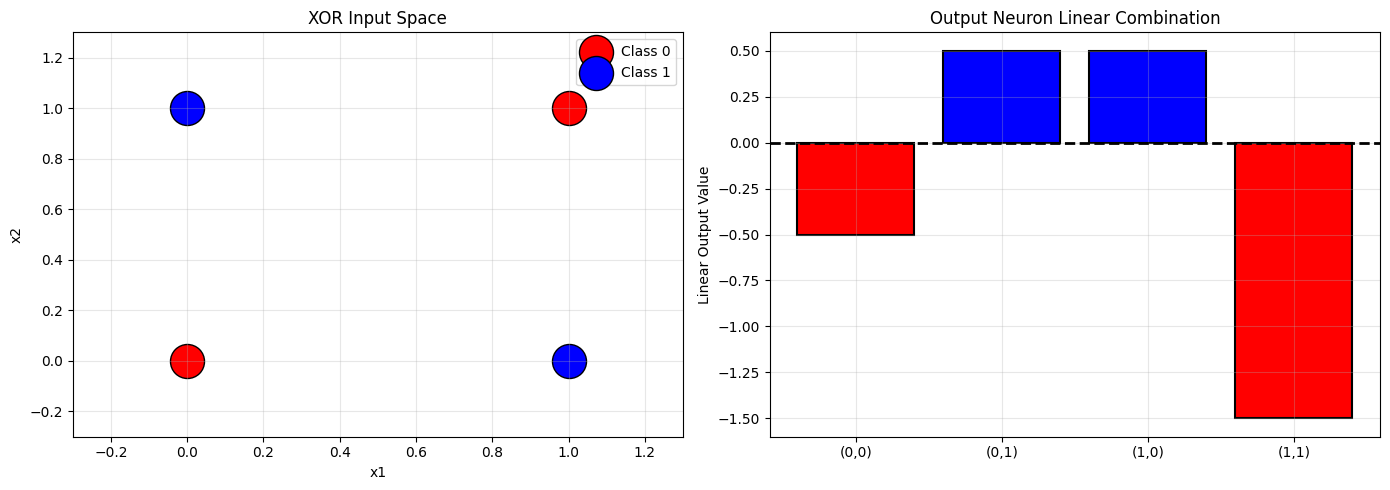


VERIFICATION
Input (0, 0): z = -0.50 => Class 0
Input (0, 1): z = 0.50 => Class 1
Input (1, 0): z = 0.50 => Class 1
Input (1, 1): z = -1.50 => Class 0


In [1]:
#XOR gate hard coded
import numpy as np
import matplotlib.pyplot as plt

# Define inputs separately (same style as AND gate)
X1 = np.array([0, 0, 1, 1])
X2 = np.array([0, 1, 0, 1])

# XOR labels
y = np.array([[0], [1], [1], [0]])

print("XOR GATE – TWO LAYER PERCEPTRON (HARD-CODED WEIGHTS)")
print("-" * 65)

# -----------------------------
# Step activation function
# -----------------------------
def step_function(x):
    return 1 if x > 0 else 0

# -----------------------------
# HARD-CODED WEIGHTS
# -----------------------------
# Hidden neuron 1 (OR-like)
w1_0 = 1.0   # weight for X1
w1_1 = 1.0   # weight for X2
b1   = -0.5

# Hidden neuron 2 (AND-like)
w2_0 = 1.0
w2_1 = 1.0
b2   = -1.5

# Output neuron
v0 = 1.0     # weight from hidden neuron 1
v1 = -2.0    # weight from hidden neuron 2
b3 = -0.5

print("\nHidden Neuron 1 (OR):  z1 = x1 + x2 - 0.5")
print("Hidden Neuron 2 (AND): z2 = x1 + x2 - 1.5")
print("Output Neuron: y = step(z1 - 2*z2 - 0.5)")

# -----------------------------
# FORWARD PASS
# -----------------------------
z1 = w1_0 * X1 + w1_1 * X2 + b1
z2 = w2_0 * X1 + w2_1 * X2 + b2

h1 = np.array([step_function(z) for z in z1])
h2 = np.array([step_function(z) for z in z2])

z_out = v0 * h1 + v1 * h2 + b3
y_pred = np.array([step_function(z) for z in z_out])

# -----------------------------
# DISPLAY RESULTS
# -----------------------------
print("\nPREDICTIONS")
for i in range(len(X1)):
    print(f"Input ({X1[i]}, {X2[i]}) | "
          f"h1 = {h1[i]}, h2 = {h2[i]} | "
          f"z_out = {z_out[i]:.2f} | "
          f"Predicted = {y_pred[i]} | Actual = {y[i][0]}")

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(14, 5))

# Input space
plt.subplot(1, 2, 1)
plt.scatter(X1[y.flatten() == 0], X2[y.flatten() == 0],
            c='red', s=600, edgecolors='black', label='Class 0')
plt.scatter(X1[y.flatten() == 1], X2[y.flatten() == 1],
            c='blue', s=600, edgecolors='black', label='Class 1')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Input Space")
plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.grid(True, alpha=0.3)
plt.legend()

# Output neuron linear values
plt.subplot(1, 2, 2)
labels = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
bar_colors = ['blue' if v > 0 else 'red' for v in z_out]

plt.bar(labels, z_out, color=bar_colors,
        edgecolor='black', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.ylabel("Linear Output Value")
plt.title("Output Neuron Linear Combination")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# FINAL VERIFICATION
# -----------------------------
print("\nVERIFICATION")
for i in range(len(X1)):
    side = "Class 1" if z_out[i] > 0 else "Class 0"
    print(f"Input ({X1[i]}, {X2[i]}): z = {z_out[i]:.2f} => {side}")
